# Breast Cancer Detection - Complete Implementation
## CBIS-DDSM Dataset - Full Design Compliance

This notebook implements the complete design specification:
- ✅ Baseline CNN model (Section 3.7.1)
- ✅ Transfer learning with two-stage training (Section 3.7.2)
- ✅ Patient-level data splitting (Section 3.5.3)
- ✅ Class imbalance handling (Section 3.7.2)
- ✅ Early stopping and checkpointing (Section 3.7.1, 3.7.2)
- ✅ Threshold selection on validation set (Section 3.10)
- ✅ Comprehensive evaluation with ROC/AUC (Section 3.10)
- ✅ Error analysis (Section 3.5.5, 3.10)
- ✅ Model comparison (Section 3.10)
- ✅ Experiment logging (Section 3.6)

In [1]:
import sys, platform
print(sys.executable)
print(platform.platform())

/mnt/c/Users/User/Desktop/Study/Level 6 Modules/Midterms - Level 6/Computer Science Final Project/cbis-ddsm-breast-cancer-image-dataset/mlnn.linux/bin/python
Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.39


### Cell 1: Imports and Configuration

In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

import tensorflow as tf
import gc
from tensorflow.keras import mixed_precision
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import EfficientNetB0, ResNet50, VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    roc_curve, auc, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)
from sklearn.utils.class_weight import compute_class_weight

# Set seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Check TensorFlow and GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        policy = mixed_precision.Policy('mixed_float16')
        mixed_precision.set_global_policy(policy)
        print('✓ Memory growth enabled')
        print('✓ Mixed precision policy: %s' % policy.compute_dtype)
    except RuntimeError as e:
        print(e)
print("TensorFlow version:", tf.__version__)
print("Physical GPUs:", gpus)
print("GPU Available:", len(gpus) > 0)

# Configuration dictionary for experiment logging
CONFIG = {
    'seed': SEED,
    'img_size': (320, 320),
    'batch_size': 12,
    'baseline_epochs': 20,
    'transfer_stage1_epochs': 10,
    'transfer_stage2_epochs': 15,
    'transfer_stage3_epochs': 15,
    'learning_rate_baseline': 0.001,
    'learning_rate_transfer_stage1': 0.0001,
    'learning_rate_transfer_stage2': 0.00001,
    'learning_rate_transfer_stage3': 0.000001,
    'dropout_rate': 0.6,
    'augmentation': {
        'rotation_range': 10,
        'width_shift_range': 0.1,
        'height_shift_range': 0.1,
        'horizontal_flip': True,
        'vertical_flip': False,
        'brightness_range': [0.9, 1.1],
        'zoom_range': 0.1
    },
    'iteration': 'Iteration 7 (VGG16 + 320x320 + Precision Feature Extraction)',
    'log_filename': 'experiment_log_v7.json',
    'experiment_date': '20260312_231339'
}

print("✓ Imports and configuration complete")
print(f"\nExperiment configuration saved with timestamp: {CONFIG['experiment_date']}")

I0000 00:00:1773902336.309111    2828 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✓ Memory growth enabled
✓ Mixed precision policy: float16
TensorFlow version: 2.21.0
Physical GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU Available: True
✓ Imports and configuration complete

Experiment configuration saved with timestamp: 20260319_143946


### Cell 2: Load Metadata CSV Files

In [3]:
print("=== Loading metadata CSVs ===")

train_mass = pd.read_csv('csv/mass_case_description_train_set.csv')
train_calc = pd.read_csv('csv/calc_case_description_train_set.csv')
test_mass = pd.read_csv('csv/mass_case_description_test_set.csv')
test_calc = pd.read_csv('csv/calc_case_description_test_set.csv')

print(f"✓ Loaded train_mass: {len(train_mass)} rows")
print(f"✓ Loaded train_calc: {len(train_calc)} rows")
print(f"✓ Loaded test_mass: {len(test_mass)} rows")
print(f"✓ Loaded test_calc: {len(test_calc)} rows")

# Check class distribution before processing
print("\n=== Initial Class Distribution ===")
for name, df in [('train_mass', train_mass), ('train_calc', train_calc)]:
    print(f"\n{name}:")
    print(df['pathology'].value_counts())

=== Loading metadata CSVs ===


✓ Loaded train_mass: 1318 rows
✓ Loaded train_calc: 1546 rows
✓ Loaded test_mass: 378 rows
✓ Loaded test_calc: 326 rows

=== Initial Class Distribution ===

train_mass:
pathology
MALIGNANT                  637
BENIGN                     577
BENIGN_WITHOUT_CALLBACK    104
Name: count, dtype: int64

train_calc:
pathology
MALIGNANT                  544
BENIGN                     528
BENIGN_WITHOUT_CALLBACK    474
Name: count, dtype: int64


### Cell 3: Data Preparation Function

In [4]:
def prepare_df_with_patient_split(df, df_name="unknown"):
    """
    Prepare dataframe with:
    1. Binary label mapping
    2. Patient ID extraction for proper splitting
    3. Path mapping to JPEG files
    """
    print(f"\nProcessing {df_name}...")
    
    # Binary labels: 1=Malignant, 0=Benign
    df['label'] = df['pathology'].apply(
        lambda x: 1 if 'MALIGNANT' in str(x).upper() else 0
    ).astype(int)
    
    print(f"  Label distribution: {df['label'].value_counts().to_dict()}")
    
    # Extract patient ID for patient-level splitting
    df['patient_id'] = df['image file path'].apply(
        lambda x: x.split('/')[0] if isinstance(x, str) else None
    )
    
    # Sample path to understand structure
    sample_path = df['image file path'].iloc[0]
    
    # Extract SeriesInstanceUID using multiple strategies
    def extract_series_uid_strategy1(path_str):
        if pd.isna(path_str) or not isinstance(path_str, str):
            return None
        parts = path_str.split('/')
        if len(parts) >= 3:
            return parts[-2]  # Second to last element
        return None
    
    def extract_series_uid_strategy2(path_str):
        if pd.isna(path_str) or not isinstance(path_str, str):
            return None
        parts = path_str.split('/')
        # Find parts that look like SeriesInstanceUID (contains dots and numbers)
        for part in parts:
            if '.' in part and len(part) > 20 and part[0].isdigit():
                return part
        return None
    
    # Try both strategies
    df['series_uid_s1'] = df['image file path'].apply(extract_series_uid_strategy1)
    df['series_uid_s2'] = df['image file path'].apply(extract_series_uid_strategy2)
    
    # Find actual JPEG files using any strategy
    def find_jpg_file_any_strategy(row):
        strategies = [row['series_uid_s1'], row['series_uid_s2']]
        
        for series_uid in strategies:
            if pd.isna(series_uid):
                continue
            
            # Try exact match
            target_dir = os.path.join('jpeg', str(series_uid))
            if os.path.exists(target_dir):
                for root, dirs, files in os.walk(target_dir):
                    for file in files:
                        if file.lower().endswith(('.jpg', '.jpeg')):
                            return os.path.join(root, file)
        
        return None
    
    df['full_path'] = df.apply(find_jpg_file_any_strategy, axis=1)
    
    found = df['full_path'].notna().sum()
    total = len(df)
    print(f"  Found {found}/{total} image files ({100*found/total:.1f}%)")
    
    # Keep only valid samples
    df_clean = df.dropna(subset=['full_path']).reset_index(drop=True)
    
    # Log patient statistics for splitting
    if len(df_clean) > 0:
        n_patients = df_clean['patient_id'].nunique()
        print(f"  Unique patients: {n_patients}")
    
    return df_clean

print("✓ Data preparation function defined")

✓ Data preparation function defined


### Cell 4: Process All Datasets

In [5]:
print("=== Processing all datasets ===")

train_mass_clean = prepare_df_with_patient_split(train_mass, "train_mass")
train_calc_clean = prepare_df_with_patient_split(train_calc, "train_calc")
test_mass_clean = prepare_df_with_patient_split(test_mass, "test_mass")
test_calc_clean = prepare_df_with_patient_split(test_calc, "test_calc")

# Combine training data
train_full = pd.concat([train_mass_clean, train_calc_clean], ignore_index=True)
test_df = pd.concat([test_mass_clean, test_calc_clean], ignore_index=True)

print(f"\n{'='*60}")
print("=== DATASET SUMMARY ===")
print(f"{'='*60}")
print(f"Total training samples: {len(train_full)}")
print(f"Total test samples: {len(test_df)}")
print(f"\nTraining class distribution:")
print(train_full['label'].value_counts())
print(f"\nTest class distribution:")
print(test_df['label'].value_counts())

# Calculate class weights for imbalance handling (Section 3.7.2)
class_weights_array = compute_class_weight(
    'balanced',
    classes=np.unique(train_full['label']),
    y=train_full['label']
)
class_weights = {i: class_weights_array[i] for i in range(len(class_weights_array))}

print(f"\nClass weights (for imbalance handling): {class_weights}")
CONFIG['class_weights'] = {str(k): float(v) for k, v in class_weights.items()}

=== Processing all datasets ===

Processing train_mass...
  Label distribution: {0: 681, 1: 637}
  Found 1318/1318 image files (100.0%)
  Unique patients: 1231

Processing train_calc...
  Label distribution: {0: 1002, 1: 544}
  Found 1546/1546 image files (100.0%)
  Unique patients: 1227

Processing test_mass...
  Label distribution: {0: 231, 1: 147}
  Found 378/378 image files (100.0%)
  Unique patients: 361

Processing test_calc...
  Label distribution: {0: 197, 1: 129}
  Found 326/326 image files (100.0%)
  Unique patients: 284

=== DATASET SUMMARY ===
Total training samples: 2864
Total test samples: 704

Training class distribution:
label
0    1683
1    1181
Name: count, dtype: int64

Test class distribution:
label
0    428
1    276
Name: count, dtype: int64

Class weights (for imbalance handling): {0: np.float64(0.8508615567439097), 1: np.float64(1.212531752751905)}


### Cell 5: Patient-Level Train/Validation Split

In [6]:
# Split by patient ID to prevent leakage (Section 3.5.3)
print("=== Creating patient-level train/validation split ===")

# Get unique patient IDs
unique_patients = train_full['patient_id'].unique()
np.random.shuffle(unique_patients)

# 80/20 split at patient level
val_split_idx = int(len(unique_patients) * 0.8)
train_patients = set(unique_patients[:val_split_idx])
val_patients = set(unique_patients[val_split_idx:])

# Assign split labels
train_full['split'] = train_full['patient_id'].apply(
    lambda x: 'train' if x in train_patients else 'val'
)

train_df = train_full[train_full['split'] == 'train'].reset_index(drop=True)
val_df = train_full[train_full['split'] == 'val'].reset_index(drop=True)

print(f"✓ Training samples: {len(train_df)}")
print(f"✓ Validation samples: {len(val_df)}")
print(f"✓ Test samples: {len(test_df)}")

print(f"\nValidation that patients don't overlap:")
train_patient_set = set(train_df['patient_id'])
val_patient_set = set(val_df['patient_id'])
overlap = train_patient_set.intersection(val_patient_set)
print(f"  Patient overlap between train/val: {len(overlap)} (should be 0)")

# Save split information for reproducibility
CONFIG['n_train_patients'] = len(train_patient_set)
CONFIG['n_val_patients'] = len(val_patient_set)
CONFIG['n_train_samples'] = len(train_df)
CONFIG['n_val_samples'] = len(val_df)
CONFIG['n_test_samples'] = len(test_df)

=== Creating patient-level train/validation split ===
✓ Training samples: 2277
✓ Validation samples: 587
✓ Test samples: 704

Validation that patients don't overlap:
  Patient overlap between train/val: 0 (should be 0)


/tmp/ipykernel_2828/1602898553.py:6: UserWarning: you are shuffling a 'StringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  np.random.shuffle(unique_patients)


### Cell 6: Create Data Generators

In [7]:
print("=== Creating data generators with CLAHE enhancement ===")

import cv2

def clahe_preprocessing(img):
    """Apply background masking and CLAHE robustly across Keras/OpenCV input formats."""
    img = np.asarray(img)

    # Keras may pass float arrays; preserve contrast before converting to uint8.
    if img.dtype != np.uint8:
        scale = 255.0 if np.max(img) <= 1.0 else 1.0
        img_uint8 = np.clip(img * scale, 0, 255).astype(np.uint8)
    else:
        img_uint8 = img

    # Handle grayscale, single-channel, or RGB inputs safely.
    if img_uint8.ndim == 2:
        gray = img_uint8
    elif img_uint8.ndim == 3 and img_uint8.shape[-1] == 1:
        gray = img_uint8[..., 0]
    else:
        gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)

    _, mask = cv2.threshold(gray, 5, 255, cv2.THRESH_BINARY)
    contours_info = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = contours_info[0] if len(contours_info) == 2 else contours_info[1]
    if contours:
        cnt = max(contours, key=cv2.contourArea)
        mask_clean = np.zeros_like(gray)
        cv2.drawContours(mask_clean, [cnt], -1, 255, -1)
        gray = cv2.bitwise_and(gray, gray, mask=mask_clean)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl1 = clahe.apply(gray)
    res = cv2.cvtColor(cl1, cv2.COLOR_GRAY2RGB)
    return res.astype(np.float32) / 255.0

IMG_SIZE = CONFIG['img_size']
BATCH_SIZE = CONFIG['batch_size']
aug = CONFIG['augmentation']

# Training: cautious, medically plausible augmentation (Section 3.7.2)
train_datagen = ImageDataGenerator(
    preprocessing_function=clahe_preprocessing,
    rotation_range=aug['rotation_range'],
    width_shift_range=aug['width_shift_range'],
    height_shift_range=aug['height_shift_range'],
    horizontal_flip=aug['horizontal_flip'],
    vertical_flip=aug.get('vertical_flip', False),
    brightness_range=aug['brightness_range'],
    zoom_range=aug['zoom_range'],
    fill_mode='constant',
    cval=0
)

# Validation and test: CLAHE + manual rescaling
val_test_datagen = ImageDataGenerator(
    preprocessing_function=clahe_preprocessing
)

# Convert label to string for flow_from_dataframe
train_df['label_str'] = train_df['label'].astype(str)
val_df['label_str'] = val_df['label'].astype(str)
test_df['label_str'] = test_df['label'].astype(str)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col='full_path',
    y_col='label_str',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    seed=SEED
)

val_gen = val_test_datagen.flow_from_dataframe(
    val_df,
    x_col='full_path',
    y_col='label_str',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    test_df,
    x_col='full_path',
    y_col='label_str',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("✓ Data generators created")
print(f"  Training: {train_gen.samples} samples")
print(f"  Validation: {val_gen.samples} samples")
print(f"  Test: {test_gen.samples} samples")

=== Creating data generators with CLAHE enhancement ===
Found 2277 validated image filenames belonging to 2 classes.
Found 587 validated image filenames belonging to 2 classes.
Found 704 validated image filenames belonging to 2 classes.
✓ Data generators created
  Training: 2277 samples
  Validation: 587 samples
  Test: 704 samples


### Cell 7: Visualize Sample Images

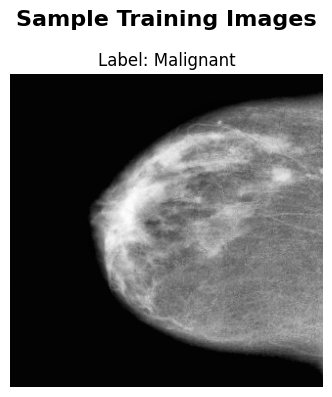

✓ Saved sample_images.png with 1 sample(s)


In [8]:
# Visualize sample images from training set
sample_images, sample_labels = next(train_gen)
n_samples = len(sample_images)
n_cols = min(4, n_samples)
n_rows = int(np.ceil(n_samples / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = np.atleast_1d(axes).ravel()

for i in range(n_samples):
    axes[i].imshow(sample_images[i])
    label = 'Malignant' if sample_labels[i] == 1 else 'Benign'
    axes[i].set_title(f'Label: {label}', fontsize=12)
    axes[i].axis('off')

for i in range(n_samples, len(axes)):
    axes[i].axis('off')

plt.suptitle('Sample Training Images', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

# Reset generator
train_gen.reset()
print(f"✓ Saved sample_images.png with {n_samples} sample(s)")

### Cell 8: Baseline CNN Model (Section 3.7.1)

In [9]:
print("="*60)
print("=== BASELINE CNN MODEL ===")
print("="*60)

def build_baseline_cnn(input_shape=(224, 224, 3), dropout_rate=0.5):
    """
    Baseline CNN as per Section 3.7.1:
    - Conv blocks with ReLU and MaxPooling
    - Global Average Pooling (reduce parameters)
    - Compact classifier with dropout
    - Sigmoid output for binary classification
    """
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        # Global Average Pooling instead of Flatten
        layers.GlobalAveragePooling2D(),
        
        # Classifier head
        layers.Dense(128, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(1, activation='sigmoid')
    ])
    
    return model

baseline_model = build_baseline_cnn(
    input_shape=(*IMG_SIZE, 3),
    dropout_rate=CONFIG['dropout_rate']
)

baseline_model.compile(
    optimizer=optimizers.Adam(learning_rate=CONFIG['learning_rate_baseline']),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

print(baseline_model.summary())
print(f"\nTotal parameters: {baseline_model.count_params():,}")

=== BASELINE CNN MODEL ===


/mnt/c/Users/User/Desktop/Study/Level 6 Modules/Midterms - Level 6/Computer Science Final Project/cbis-ddsm-breast-cancer-image-dataset/mlnn.linux/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1773902406.500132    2828 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4084 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 320, 320, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 320, 320, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 160, 160, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 160, 160, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 80, 80, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 80, 80, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 40, 40, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 303,649 (1.16 MB)

 Trainable params: 303,649 (1.16 MB)

 Non-trainable params: 0 (0.00 B)

None

Total parameters: 303,649


### Cell 9: Train Baseline Model

In [10]:
print("=== Training Baseline CNN ===")

# Callbacks: Early stopping and checkpointing (Section 3.7.1)
baseline_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_auc',
        patience=5,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        'baseline_best.keras',
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

baseline_history = baseline_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=CONFIG['baseline_epochs'],
    class_weight=class_weights,  # Handle imbalance
    callbacks=baseline_callbacks,
    verbose=1
)

print("\n✓ Baseline training complete")
best_val_auc = max(baseline_history.history['val_auc'])
print(f"Best validation AUC: {best_val_auc:.4f}")
CONFIG['baseline_best_val_auc'] = float(best_val_auc)

# --- Persist history so the notebook survives WSL/kernel crashes ---
import json as _json
with open('baseline_history.json', 'w') as _f:
    _json.dump(baseline_history.history, _f)
print('✓ baseline_history saved to baseline_history.json')

=== Training Baseline CNN ===
Epoch 1/20


I0000 00:00:1773902411.163645    2828 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1773902414.247950    3416 service.cc:153] XLA service 0x2fed40c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773902414.247994    3416 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce GTX 1660 SUPER, Compute Capability 7.5 (Driver: 12.9.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1773902414.530146    3416 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1773902415.370121    3416 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1773902447.746252    3416 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2277/2277 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.5294 - auc: 0.4867 - loss: 0.6943
Epoch 1: val_auc improved from None to 0.50000, saving model to baseline_best.keras

Epoch 1: finished saving model to baseline_best.keras
2277/2277 ━━━━━━━━━━━━━━━━━━━━ 384s 153ms/step - accuracy: 0.5077 - auc: 0.4887 - loss: 0.6955 - val_accuracy: 0.3918 - val_auc: 0.5000 - val_loss: 0.6942 - learning_rate: 0.0010
Epoch 2/20
2277/2277 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.5064 - auc: 0.5037 - loss: 0.6910
Epoch 2: val_auc did not improve from 0.50000
2277/2277 ━━━━━━━━━━━━━━━━━━━━ 327s 144ms/step - accuracy: 0.4958 - auc: 0.5059 - loss: 0.6943 - val_accuracy: 0.3918 - val_auc: 0.5000 - val_loss: 0.6969 - learning_rate: 0.0010
Epoch 3/20
2277/2277 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.4537 - auc: 0.4916 - loss: 0.6967
Epoch 3: val_auc did not improve from 0.50000
2277/2277 ━━━━━━━━━━━━━━━━━━━━ 329s 144ms/step - accuracy: 0.4537 - auc: 0.4926 - loss: 0.6953 - val_accuracy:

### Cell 10: Transfer Learning Model (Section 3.7.2)

In [11]:
print("="*60)
print("=== TRANSFER LEARNING MODEL ===")
print("="*60)

def build_transfer_model(backbone='efficientnet', input_shape=(224, 224, 3), dropout_rate=0.5):
    """
    Transfer learning model as per Section 3.7.2:
    - Pretrained backbone (EfficientNetB0/ResNet50/VGG16)
    - Custom classifier head
    - Two-stage training capability (freeze/unfreeze)
    """
    if backbone == 'efficientnet':
        base_model = EfficientNetB0(
            include_top=False,
            weights='imagenet',
            input_shape=input_shape
        )
    elif backbone == 'resnet50':
        base_model = ResNet50(
            include_top=False,
            weights='imagenet',
            input_shape=input_shape
        )
    elif backbone == 'vgg16':
        base_model = VGG16(
            include_top=False,
            weights='imagenet',
            input_shape=input_shape
        )
    
    # Freeze backbone initially (Stage 1)
    base_model.trainable = False
    
    # Build complete model
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(1, activation='sigmoid', dtype='float32')
    ])
    
    return model, base_model

# Build transfer learning model
if 'baseline_model' in globals():
    del baseline_model
tf.keras.backend.clear_session()
gc.collect()
print('✓ GPU memory cleared')
transfer_model, backbone = build_transfer_model(
    backbone='vgg16',
    input_shape=(*IMG_SIZE, 3),
    dropout_rate=CONFIG['dropout_rate']
)

transfer_model.compile(
    optimizer=optimizers.Adam(learning_rate=CONFIG['learning_rate_transfer_stage1']),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

print(f"\nBackbone frozen: {not backbone.trainable}")
print(f"Total parameters: {transfer_model.count_params():,}")
trainable_params = sum([tf.size(w).numpy() for w in transfer_model.trainable_weights])
print(f"Trainable parameters (Stage 1): {trainable_params:,}")

CONFIG['transfer_backbone'] = 'VGG16'
CONFIG['transfer_total_params'] = int(transfer_model.count_params())

=== TRANSFER LEARNING MODEL ===
✓ GPU memory cleared

Backbone frozen: True
Total parameters: 14,780,481
Trainable parameters (Stage 1): 65,793


### Cell 11: Train Transfer Model - Stage 1 (Frozen Backbone)

In [12]:
print("=== Stage 1: Training with frozen backbone ===")
print("Optimizing only the classifier head...\n")

lr_scheduler = callbacks.ReduceLROnPlateau(
    monitor='val_auc', 
    factor=0.5, 
    patience=3, 
    min_lr=1e-7, 
    mode='max', 
    verbose=1
)

transfer_callbacks_stage1 = [
    callbacks.EarlyStopping(
        monitor='val_auc',
        patience=5,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        'transfer_stage1_best.keras',
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    lr_scheduler
]

history_stage1 = transfer_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=CONFIG['transfer_stage1_epochs'],
    class_weight=class_weights,
    callbacks=transfer_callbacks_stage1,
    verbose=1
)

print("\n✓ Stage 1 complete")
stage1_best = max(history_stage1.history['val_auc'])
print(f"Best validation AUC (Stage 1): {stage1_best:.4f}")
CONFIG['transfer_stage1_best_val_auc'] = float(stage1_best)

# --- Persist history so the notebook survives WSL/kernel crashes ---
import json as _json
with open('history_stage1.json', 'w') as _f:
    _json.dump(history_stage1.history, _f)
print('✓ history_stage1 saved to history_stage1.json')

=== Stage 1: Training with frozen backbone ===
Optimizing only the classifier head...

Epoch 1/10


W0000 00:00:1773904481.221456   10485 hlo_rematerialization.cc:3204] Can't reduce memory use below 4.55GiB (4883656382 bytes) by rematerialization; only reduced to 8.14GiB (8738373664 bytes), down from 8.14GiB (8738373664 bytes) originally
W0000 00:00:1773904492.245589    3416 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 8.13GiB (rounded to 8725266944)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1773904492.264645    3416 bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_bfc
I0000 00:00:1773904492.264662    3416 bfc_allocator.cc:1056] Bin (256): 	Total Chunks: 80, Chunks in use: 80. 20.0KiB allocated for chunks. 20.0KiB in use in bin. 3.1KiB client-requested in use in bin.
I0000 00:00:1773904492.264678    3416 bfc_allocator.cc:1056] Bin (512): 	Total Chunks: 18, C

W0000 00:00:1773904534.839271    3416 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.14GiB (rounded to 4442554880)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1773904534.839336    3416 bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_bfc
I0000 00:00:1773904534.839342    3416 bfc_allocator.cc:1056] Bin (256): 	Total Chunks: 84, Chunks in use: 84. 21.0KiB allocated for chunks. 21.0KiB in use in bin. 3.1KiB client-requested in use in bin.
I0000 00:00:1773904534.839347    3416 bfc_allocator.cc:1056] Bin (512): 	Total Chunks: 18, Chunks in use: 18. 9.0KiB allocated for chunks. 9.0KiB in use in bin. 9.0KiB client-requested in use in bin.
I0000 00:00:1773904534.839349    3416 bfc_allocator.cc:1056] Bin (1024): 	Total Chunks: 12, Chunks in use: 12. 13.0KiB allocated for

2277/2277 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.4677 - auc: 0.4694 - loss: 0.7639
Epoch 1: val_auc improved from None to 0.62528, saving model to transfer_stage1_best.keras

Epoch 1: finished saving model to transfer_stage1_best.keras
2277/2277 ━━━━━━━━━━━━━━━━━━━━ 421s 152ms/step - accuracy: 0.4875 - auc: 0.4850 - loss: 0.7392 - val_accuracy: 0.3918 - val_auc: 0.6253 - val_loss: 0.7248 - learning_rate: 1.0000e-04
Epoch 2/10
2277/2277 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.5067 - auc: 0.5303 - loss: 0.6989
Epoch 2: val_auc improved from 0.62528 to 0.68036, saving model to transfer_stage1_best.keras

Epoch 2: finished saving model to transfer_stage1_best.keras
2277/2277 ━━━━━━━━━━━━━━━━━━━━ 344s 151ms/step - accuracy: 0.5051 - auc: 0.5260 - loss: 0.6997 - val_accuracy: 0.6218 - val_auc: 0.6804 - val_loss: 0.6788 - learning_rate: 1.0000e-04
Epoch 3/10
2277/2277 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.5648 - auc: 0.5461 - loss: 0.6848
Epoch 3: val_auc improve

### Cell 12: Train Transfer Model - Stage 2 (Fine-tuning)

In [13]:
print("=== Stage 2: Partial Fine-tuning (VGG Block 5 Only) ===")

backbone.trainable = True
# On a 4 GB GPU, keep fine-tuning limited to the top VGG block.
for layer in backbone.layers:
    layer.trainable = layer.name.startswith('block5')

print(f"Backbone trainable: {backbone.trainable}")
trainable_params = sum([tf.size(w).numpy() for w in transfer_model.trainable_weights])
print(f"Trainable parameters (Stage 2): {trainable_params:,}\n")

transfer_model.compile(
    optimizer=optimizers.Adam(learning_rate=CONFIG['learning_rate_transfer_stage2']),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

transfer_callbacks_stage2 = [
    callbacks.EarlyStopping(monitor='val_auc', patience=5, mode='max', restore_best_weights=True, verbose=1),
    callbacks.ModelCheckpoint('transfer_stage2_best.keras', monitor='val_auc', mode='max', save_best_only=True, verbose=1),
    lr_scheduler
]

history_stage2 = transfer_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=CONFIG['transfer_stage2_epochs'],
    class_weight=class_weights,
    callbacks=transfer_callbacks_stage2,
    verbose=1
)

print("\n✓ Stage 2 complete")
stage2_best = max(history_stage2.history['val_auc'])
print(f"Best validation AUC (Stage 2): {stage2_best:.4f}")
CONFIG['transfer_stage2_best_val_auc'] = float(stage2_best)

# --- Persist history so the notebook survives WSL/kernel crashes ---
import json as _json
with open('history_stage2.json', 'w') as _f:
    _json.dump(history_stage2.history, _f)
print('✓ history_stage2 saved to history_stage2.json')

=== Stage 2: Partial Fine-tuning (VGG Block 5 Only) ===
Backbone trainable: True
Trainable parameters (Stage 2): 7,145,217

Epoch 1/15
 155/2277 ━━━━━━━━━━━━━━━━━━━━ 4:44 134ms/step - accuracy: 0.5025 - auc: 0.4647 - loss: 0.6969

2277/2277 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.5274 - auc: 0.5440 - loss: 0.6931
Epoch 1: val_auc improved from None to 0.70067, saving model to transfer_stage2_best.keras

Epoch 1: finished saving model to transfer_stage2_best.keras
2277/2277 ━━━━━━━━━━━━━━━━━━━━ 358s 151ms/step - accuracy: 0.5494 - auc: 0.5649 - loss: 0.6896 - val_accuracy: 0.6491 - val_auc: 0.7007 - val_loss: 0.6325 - learning_rate: 1.0000e-05
Epoch 2/15
2277/2277 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.5677 - auc: 0.5969 - loss: 0.6813
Epoch 2: val_auc improved from 0.70067 to 0.70742, saving model to transfer_stage2_best.keras

Epoch 2: finished saving model to transfer_stage2_best.keras
2277/2277 ━━━━━━━━━━━━━━━━━━━━ 348s 153ms/step - accuracy: 0.5845 - auc: 0.6115 - loss: 0.6782 - val_accuracy: 0.6354 - val_auc: 0.7074 - val_loss: 0.6336 - learning_rate: 1.0000e-05
Epoch 3/15
2277/2277 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.5996 - auc: 0.6284 - loss: 0.6755
Epoch 3: val_auc improve

### Cell 13: Train Transfer Model - Stage 3 (Full Fine-tuning)

In [ ]:
print("=== Stage 3: Optional Deeper Fine-tuning ===")

if CONFIG['transfer_stage3_epochs'] <= 0:
    print("Skipping Stage 3 to avoid GPU OOM at 320x320 on 4 GB VRAM.")
    history_stage3 = None
    CONFIG['transfer_stage3_best_val_auc'] = None
else:
    # If you later have more VRAM, expand fine-tuning to VGG blocks 4 and 5.
    backbone.trainable = True
    for layer in backbone.layers:
        layer.trainable = layer.name.startswith('block4') or layer.name.startswith('block5')

    print(f"Backbone trainable: {backbone.trainable}")
    trainable_params = sum([tf.size(w).numpy() for w in transfer_model.trainable_weights])
    print(f"Trainable parameters (Stage 3): {trainable_params:,}\n")

    transfer_model.compile(
        optimizer=optimizers.Adam(learning_rate=CONFIG['learning_rate_transfer_stage3']),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )

    transfer_callbacks_stage3 = [
        callbacks.EarlyStopping(monitor='val_auc', patience=5, mode='max', restore_best_weights=True, verbose=1),
        callbacks.ModelCheckpoint('transfer_stage3_best.keras', monitor='val_auc', mode='max', save_best_only=True, verbose=1),
        lr_scheduler
    ]

    history_stage3 = transfer_model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=CONFIG['transfer_stage3_epochs'],
        class_weight=class_weights,
        callbacks=transfer_callbacks_stage3,
        verbose=1
    )

    print("\n✓ Stage 3 complete")
    stage3_best = max(history_stage3.history['val_auc'])
    print(f"Best validation AUC (Stage 3): {stage3_best:.4f}")
    CONFIG['transfer_stage3_best_val_auc'] = float(stage3_best)

# --- Persist history so the notebook survives WSL/kernel crashes ---
import json as _json
with open('history_stage3.json', 'w') as _f:
    _json.dump(history_stage3.history, _f)
print('✓ history_stage3 saved to history_stage3.json')

=== Stage 3: Optional Deeper Fine-tuning ===
Backbone trainable: True
Trainable parameters (Stage 3): 13,044,993

Epoch 1/15


W0000 00:00:1773911891.832137   33616 hlo_rematerialization.cc:3204] Can't reduce memory use below 4.55GiB (4884097290 bytes) by rematerialization; only reduced to 8.28GiB (8888385568 bytes), down from 8.28GiB (8888385568 bytes) originally
W0000 00:00:1773911902.951316    3418 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 8.27GiB (rounded to 8885109248)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1773911902.956225    3418 bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_bfc
I0000 00:00:1773911902.956231    3418 bfc_allocator.cc:1056] Bin (256): 	Total Chunks: 145, Chunks in use: 145. 36.2KiB allocated for chunks. 36.2KiB in use in bin. 3.4KiB client-requested in use in bin.
I0000 00:00:1773911902.956237    3418 bfc_allocator.cc:1056] Bin (512): 	Total Chunks: 26,

2277/2277 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.6514 - auc: 0.7101 - loss: 0.6265
Epoch 1: val_auc improved from None to 0.74787, saving model to transfer_stage3_best.keras

Epoch 1: finished saving model to transfer_stage3_best.keras
2277/2277 ━━━━━━━━━━━━━━━━━━━━ 406s 154ms/step - accuracy: 0.6539 - auc: 0.7208 - loss: 0.6139 - val_accuracy: 0.6729 - val_auc: 0.7479 - val_loss: 0.5829 - learning_rate: 1.0000e-06
Epoch 2/15
2277/2277 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.6847 - auc: 0.7444 - loss: 0.5955
Epoch 2: val_auc improved from 0.74787 to 0.75368, saving model to transfer_stage3_best.keras

Epoch 2: finished saving model to transfer_stage3_best.keras
2277/2277 ━━━━━━━━━━━━━━━━━━━━ 350s 153ms/step - accuracy: 0.6785 - auc: 0.7493 - loss: 0.5943 - val_accuracy: 0.6695 - val_auc: 0.7537 - val_loss: 0.5780 - learning_rate: 1.0000e-06
Epoch 3/15
2277/2277 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.6743 - auc: 0.7234 - loss: 0.6146
Epoch 3: val_auc improve

### Cell 14: Visualize Training History

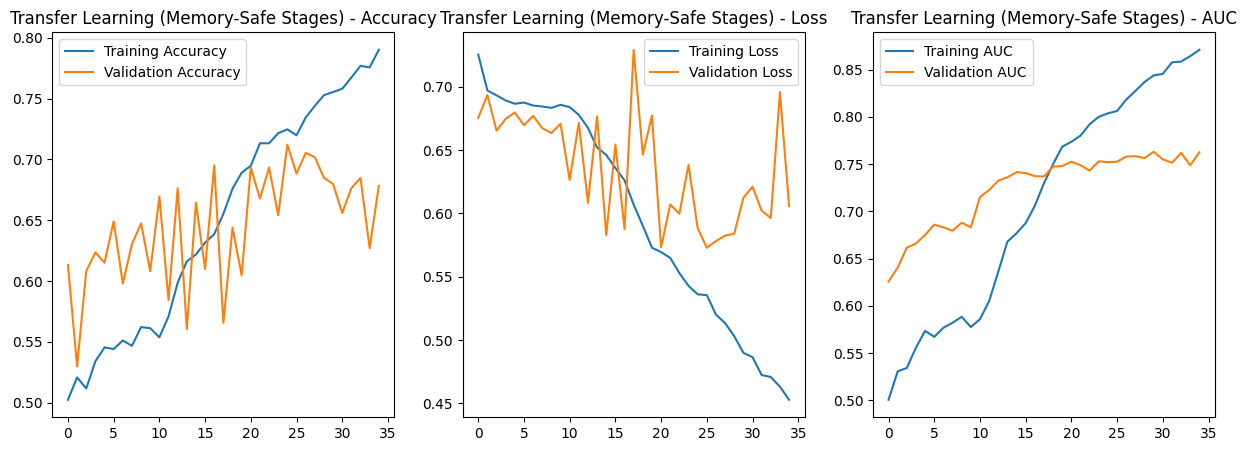

In [ ]:
# --- Restore history objects from disk if kernel was restarted ---
import json as _json, os as _os

def _load_history(path):
    if not _os.path.exists(path):
        return None
    with open(path) as _f:
        return type('History', (), {'history': _json.load(_f)})()

if 'history_stage1' not in globals() or history_stage1 is None:
    history_stage1 = _load_history('history_stage1.json')
if 'history_stage2' not in globals() or history_stage2 is None:
    history_stage2 = _load_history('history_stage2.json')
if 'history_stage3' not in globals() or history_stage3 is None:
    history_stage3 = _load_history('history_stage3.json')

# Plot combined training history for the completed stages.
def plot_training_history(h1, h2, h3, title):
    histories = [h for h in [h1, h2, h3] if h is not None]
    acc = sum((h.history['accuracy'] for h in histories), [])
    val_acc = sum((h.history['val_accuracy'] for h in histories), [])
    loss = sum((h.history['loss'] for h in histories), [])
    val_loss = sum((h.history['val_loss'] for h in histories), [])
    auc = sum((h.history['auc'] for h in histories), [])
    val_auc = sum((h.history['val_auc'] for h in histories), [])
    
    epochs_range = range(len(acc))
    
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.legend()
    
    plt.subplot(1, 3, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.legend()
    
    plt.subplot(1, 3, 3)
    plt.plot(epochs_range, auc, label='Training AUC')
    plt.plot(epochs_range, val_auc, label='Validation AUC')
    plt.title(f'{title} - AUC')
    plt.legend()
    plt.show()

plot_training_history(history_stage1, history_stage2, history_stage3, 'Transfer Learning (Memory-Safe Stages)')

### Cell 15: Threshold Selection on Validation Set (Section 3.10)

In [ ]:
print("="*60)
print("=== THRESHOLD SELECTION (VALIDATION SET) ===")
print("="*60)

# Ensure mixed precision policy is set for loading models
from tensorflow.keras import mixed_precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)
print('✓ Mixed precision policy set for model loading')

# Load models if they are not present in the current notebook kernel.
if 'baseline_model' not in globals() or baseline_model is None:
    print("Loading saved baseline model for threshold selection...")
    try:
        baseline_model = tf.keras.models.load_model('baseline_best.keras')
        print("✓ Baseline model loaded successfully")
    except Exception as e:
        print(f"❌ Failed to load baseline model: {e}")
        raise

if 'transfer_model' not in globals() or transfer_model is None:
    print("Loading saved transfer model for threshold selection...")
    transfer_checkpoint = 'transfer_stage3_best.keras' if os.path.exists('transfer_stage3_best.keras') else 'transfer_stage2_best.keras'
    try:
        transfer_model = tf.keras.models.load_model(transfer_checkpoint)
        print("✓ Transfer model loaded successfully")
    except Exception as e:
        print(f"❌ Failed to load transfer model: {e}")
        raise

# Get predictions on validation set
val_gen.reset()
val_pred_baseline = baseline_model.predict(val_gen, verbose=0)
val_gen.reset()
val_pred_transfer = transfer_model.predict(val_gen, verbose=0)
val_true = val_gen.classes

# Find optimal threshold using Youden's J statistic (Section 3.10)
def find_optimal_threshold(y_true, y_pred_proba):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    # Youden's J = Sensitivity + Specificity - 1
    youdens_j = tpr - fpr
    optimal_idx = np.argmax(youdens_j)
    optimal_threshold = thresholds[optimal_idx]
    return optimal_threshold, tpr[optimal_idx], 1 - fpr[optimal_idx]

# Find thresholds for both models
baseline_threshold, baseline_sens, baseline_spec = find_optimal_threshold(val_true, val_pred_baseline)
transfer_threshold, transfer_sens, transfer_spec = find_optimal_threshold(val_true, val_pred_transfer)

print("\nBaseline Model:")
print(f"  Optimal threshold: {baseline_threshold:.4f}")
print(f"  Sensitivity at threshold: {baseline_sens:.4f}")
print(f"  Specificity at threshold: {baseline_spec:.4f}")

print("\nTransfer Learning Model:")
print(f"  Optimal threshold: {transfer_threshold:.4f}")
print(f"  Sensitivity at threshold: {transfer_sens:.4f}")
print(f"  Specificity at threshold: {transfer_spec:.4f}")

# Save thresholds to config
CONFIG['baseline_threshold'] = float(baseline_threshold)
CONFIG['transfer_threshold'] = float(transfer_threshold)

=== THRESHOLD SELECTION (VALIDATION SET) ===
✓ Mixed precision policy set for model loading
Loading saved baseline model for threshold selection...
✓ Baseline model loaded successfully


I0000 00:00:1773803323.283433    2368 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1773803323.509259    3362 service.cc:153] XLA service 0x7b9c9c02eb60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773803323.509300    3362 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce GTX 1660 SUPER, Compute Capability 7.5 (Driver: 12.9.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1773803323.590579    3362 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1773803323.751525    3362 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1773803331.980156    3362 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
W0000 00:00:1773803399.951865    4261 hlo_rematerialization.cc:3204] Can't reduce memory use below 4.55GiB (4883656382 bytes) 


Baseline Model:
  Optimal threshold: inf
  Sensitivity at threshold: 0.0000
  Specificity at threshold: 1.0000

Transfer Learning Model:
  Optimal threshold: 0.3875
  Sensitivity at threshold: 0.7870
  Specificity at threshold: 0.3109


### Cell 16: Test Set Evaluation

In [ ]:
print("="*60)
print("=== TEST SET EVALUATION ===")
print("="*60)

# Get predictions on test set
test_gen.reset()
test_pred_baseline_proba = baseline_model.predict(test_gen, verbose=0)
test_gen.reset()
test_pred_transfer_proba = transfer_model.predict(test_gen, verbose=0)
test_true = test_gen.classes

# Apply thresholds determined on validation set
test_pred_baseline = (test_pred_baseline_proba > baseline_threshold).astype(int)
test_pred_transfer = (test_pred_transfer_proba > transfer_threshold).astype(int)

# Calculate metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def calculate_metrics(y_true, y_pred, y_pred_proba):
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred),  # Sensitivity
        'specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'f1': f1_score(y_true, y_pred),
        'auc': roc_auc,
        'confusion_matrix': cm
    }

baseline_metrics = calculate_metrics(test_true, test_pred_baseline.flatten(), test_pred_baseline_proba.flatten())
transfer_metrics = calculate_metrics(test_true, test_pred_transfer.flatten(), test_pred_transfer_proba.flatten())

# Print comparison table (Section 3.10)
print("\n" + "="*60)
print("MODEL COMPARISON (Test Set)")
print("="*60)
print(f"{'Metric':<15} {'Baseline CNN':<15} {'Transfer Learning':<20}")
print("-"*60)
for metric in ['accuracy', 'precision', 'recall', 'specificity', 'f1', 'auc']:
    baseline_val = baseline_metrics[metric]
    transfer_val = transfer_metrics[metric]
    improvement = "" if metric == 'auc' else ""
    print(f"{metric.capitalize():<15} {baseline_val:<15.4f} {transfer_val:<20.4f}")
print("="*60)

# Save to config for logging
CONFIG['test_results'] = {
    'baseline': {k: float(v) if not isinstance(v, np.ndarray) else v.tolist() 
                 for k, v in baseline_metrics.items()},
    'transfer': {k: float(v) if not isinstance(v, np.ndarray) else v.tolist() 
                 for k, v in transfer_metrics.items()}
}

=== TEST SET EVALUATION ===

MODEL COMPARISON (Test Set)
Metric          Baseline CNN    Transfer Learning   
------------------------------------------------------------
Accuracy        0.6080          0.4474              
Precision       0.0000          0.3952              
Recall          0.0000          0.7717              
Specificity     1.0000          0.2383              
F1              0.0000          0.5227              
Auc             0.5000          0.5093              


### Cell 17: Visualize Training History

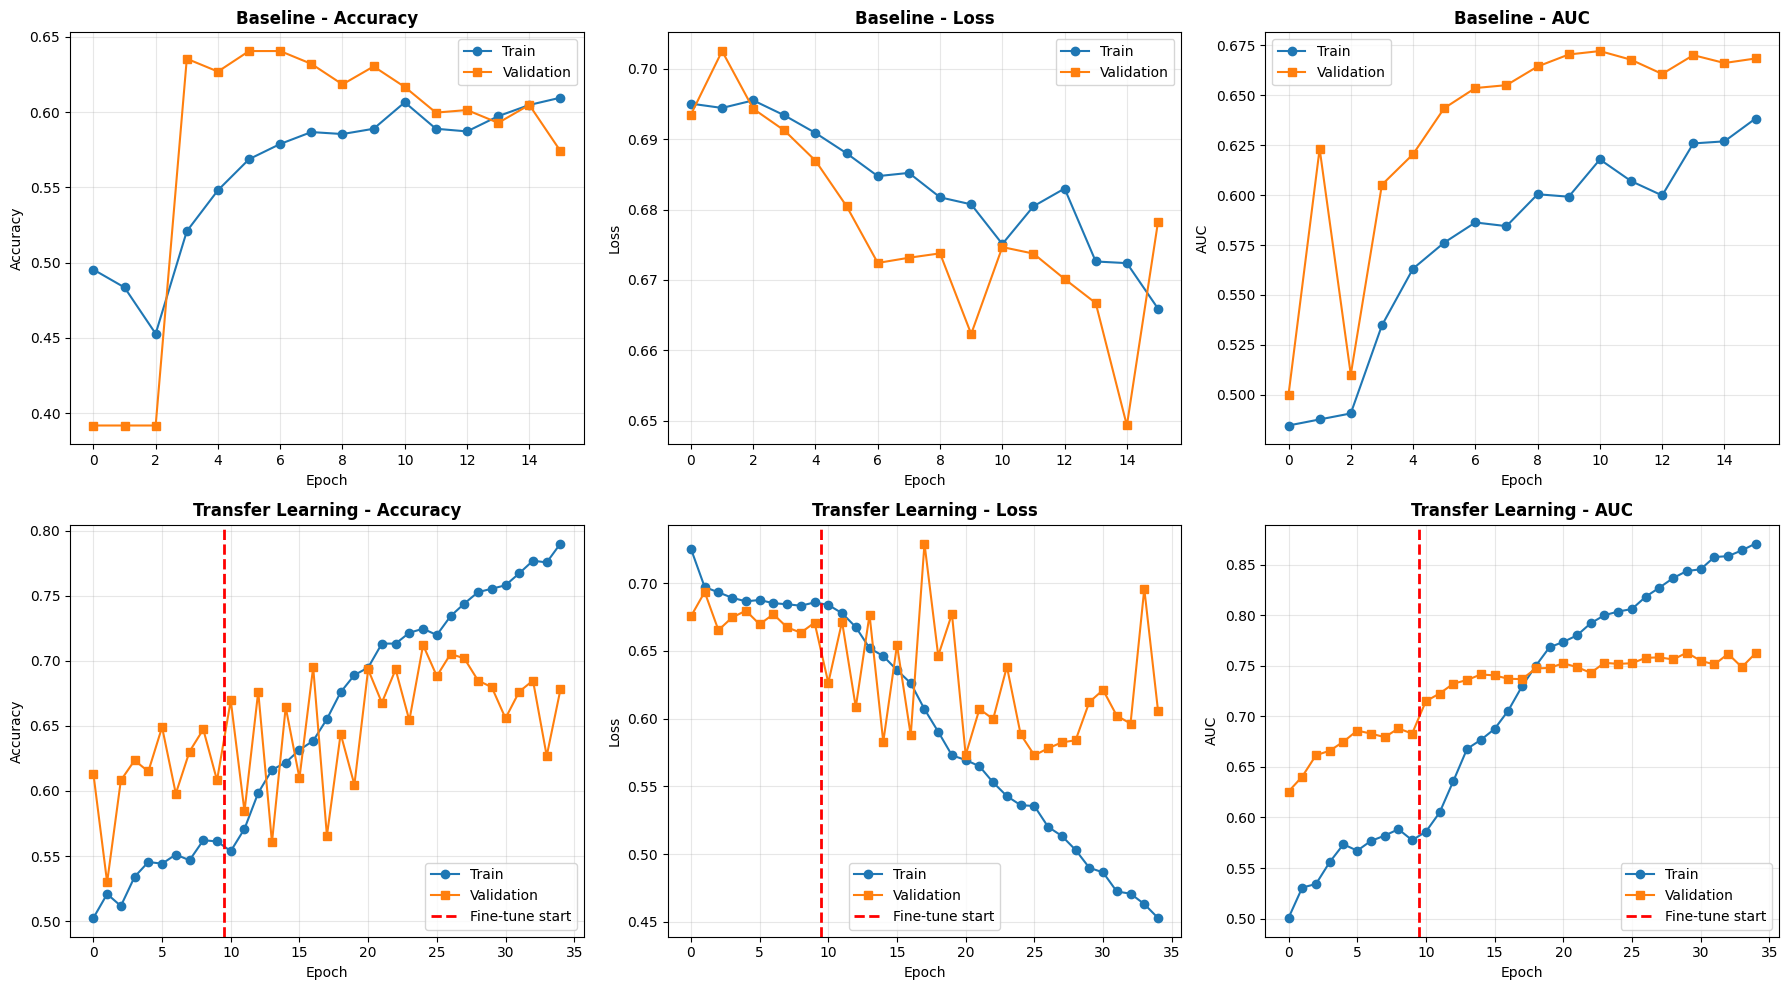

✓ Saved training_curves_comparison.png


In [ ]:
# Plot training curves for both models
from pathlib import Path

METRICS = ['accuracy', 'val_accuracy', 'loss', 'val_loss', 'auc', 'val_auc']

def history_to_dict(history_obj):
    return {metric: list(history_obj.history[metric]) for metric in METRICS}

def find_history_csv(patterns):
    for pattern in patterns:
        matches = sorted(Path('.').glob(pattern))
        if matches:
            return matches[-1]
    return None

baseline_history_metrics = None
if 'baseline_history' in globals() and baseline_history is not None:
    baseline_history_metrics = history_to_dict(baseline_history)
else:
    baseline_csv = find_history_csv([
        'baseline_training_history.csv',
        'baseline_training_history_v*.csv',
        'archive/baseline_training_history_v*.csv'
    ])
    if baseline_csv is not None:
        baseline_history_metrics = pd.read_csv(baseline_csv).to_dict(orient='list')

if baseline_history_metrics is None:
    raise NameError(
        "baseline_history is not defined. Run the baseline training cell first or make sure a baseline_training_history CSV file exists."
    )

transfer_history_metrics = None
stage1_end = None
if all(name in globals() and globals()[name] is not None for name in ('history_stage1', 'history_stage2')):
    stage_histories = [history_stage1, history_stage2]
    if 'history_stage3' in globals() and history_stage3 is not None:
        stage_histories.append(history_stage3)
    transfer_history_metrics = {
        metric: sum((list(history.history[metric]) for history in stage_histories), [])
        for metric in METRICS
    }
    stage1_end = len(history_stage1.history['accuracy'])
else:
    transfer_csv = find_history_csv([
        'transfer_training_history.csv',
        'transfer_training_history_v*.csv',
        'archive/transfer_training_history_v*.csv'
    ])
    if transfer_csv is not None:
        transfer_df = pd.read_csv(transfer_csv)
        transfer_history_metrics = {metric: transfer_df[metric].tolist() for metric in METRICS}
        stage1_end = int((transfer_df['stage'] == 'stage1').sum())

if transfer_history_metrics is None or stage1_end is None:
    raise NameError(
        "Transfer training history is not available. Run the transfer training cells first or make sure a transfer_training_history CSV file exists."
    )

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Baseline
axes[0, 0].plot(baseline_history_metrics['accuracy'], label='Train', marker='o')
axes[0, 0].plot(baseline_history_metrics['val_accuracy'], label='Validation', marker='s')
axes[0, 0].set_title('Baseline - Accuracy', fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(baseline_history_metrics['loss'], label='Train', marker='o')
axes[0, 1].plot(baseline_history_metrics['val_loss'], label='Validation', marker='s')
axes[0, 1].set_title('Baseline - Loss', fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

axes[0, 2].plot(baseline_history_metrics['auc'], label='Train', marker='o')
axes[0, 2].plot(baseline_history_metrics['val_auc'], label='Validation', marker='s')
axes[0, 2].set_title('Baseline - AUC', fontweight='bold')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('AUC')
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.3)

# Transfer Learning
axes[1, 0].plot(transfer_history_metrics['accuracy'], label='Train', marker='o')
axes[1, 0].plot(transfer_history_metrics['val_accuracy'], label='Validation', marker='s')
axes[1, 0].axvline(x=stage1_end - 0.5, color='r', linestyle='--', linewidth=2, label='Fine-tune start')
axes[1, 0].set_title('Transfer Learning - Accuracy', fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(transfer_history_metrics['loss'], label='Train', marker='o')
axes[1, 1].plot(transfer_history_metrics['val_loss'], label='Validation', marker='s')
axes[1, 1].axvline(x=stage1_end - 0.5, color='r', linestyle='--', linewidth=2, label='Fine-tune start')
axes[1, 1].set_title('Transfer Learning - Loss', fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

axes[1, 2].plot(transfer_history_metrics['auc'], label='Train', marker='o')
axes[1, 2].plot(transfer_history_metrics['val_auc'], label='Validation', marker='s')
axes[1, 2].axvline(x=stage1_end - 0.5, color='r', linestyle='--', linewidth=2, label='Fine-tune start')
axes[1, 2].set_title('Transfer Learning - AUC', fontweight='bold')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('AUC')
axes[1, 2].legend()
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved training_curves_comparison.png")

### Cell 18: ROC Curves Comparison

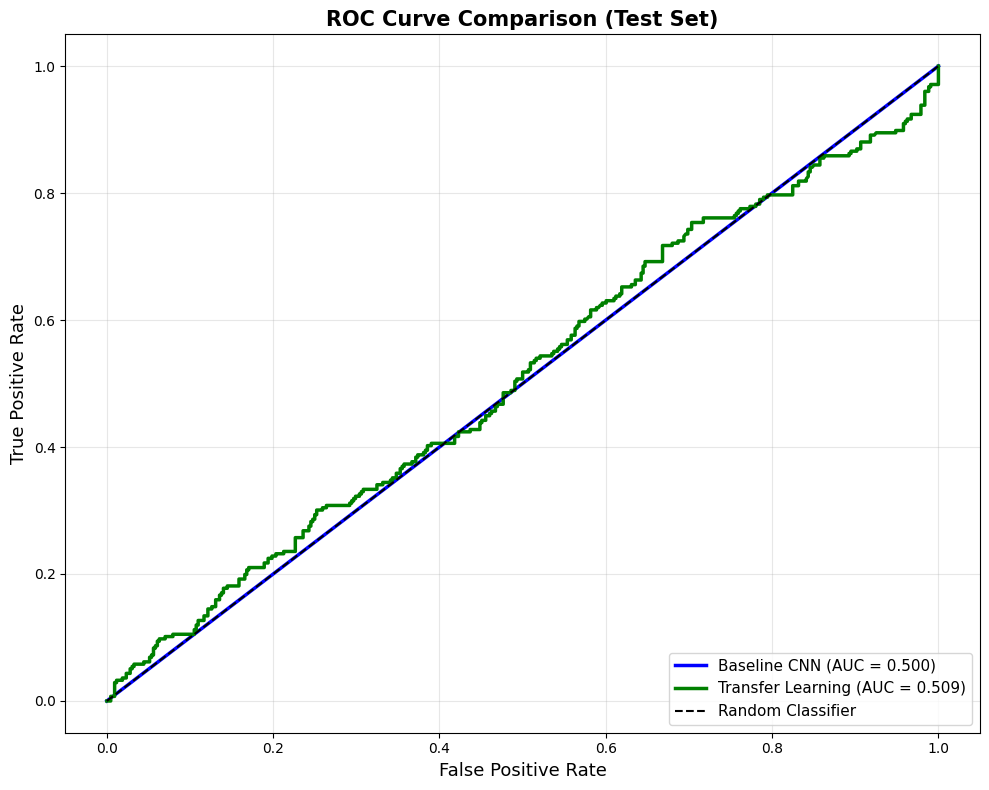

✓ Saved roc_curves_comparison.png


In [ ]:
# ROC curves for both models
fig, ax = plt.subplots(figsize=(10, 8))

# Baseline
fpr_baseline, tpr_baseline, _ = roc_curve(test_true, test_pred_baseline_proba)
auc_baseline = auc(fpr_baseline, tpr_baseline)

# Transfer
fpr_transfer, tpr_transfer, _ = roc_curve(test_true, test_pred_transfer_proba)
auc_transfer = auc(fpr_transfer, tpr_transfer)

# Plot
ax.plot(fpr_baseline, tpr_baseline, linewidth=2.5, 
        label=f'Baseline CNN (AUC = {auc_baseline:.3f})', color='blue')
ax.plot(fpr_transfer, tpr_transfer, linewidth=2.5, 
        label=f'Transfer Learning (AUC = {auc_transfer:.3f})', color='green')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')

ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curve Comparison (Test Set)', fontsize=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved roc_curves_comparison.png")

### Cell 19: Confusion Matrices

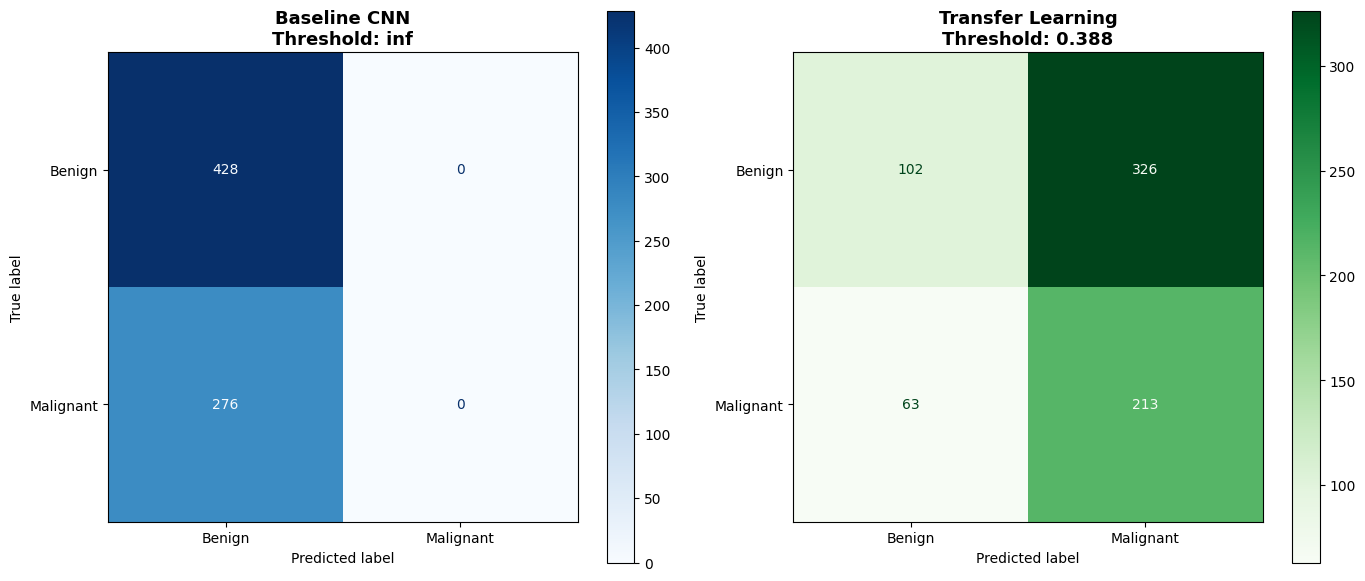

✓ Saved confusion_matrices_comparison.png


In [ ]:
# Plot confusion matrices side by side
if 'baseline_metrics' not in globals() or 'confusion_matrix' not in baseline_metrics:
    baseline_metrics = calculate_metrics(
        test_true,
        test_pred_baseline.flatten(),
        test_pred_baseline_proba.flatten()
    )

if 'transfer_metrics' not in globals() or 'confusion_matrix' not in transfer_metrics:
    transfer_metrics = calculate_metrics(
        test_true,
        test_pred_transfer.flatten(),
        test_pred_transfer_proba.flatten()
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Baseline
disp1 = ConfusionMatrixDisplay(
    confusion_matrix=baseline_metrics['confusion_matrix'],
    display_labels=['Benign', 'Malignant']
)
disp1.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title(f"Baseline CNN\nThreshold: {baseline_threshold:.3f}", fontweight='bold', fontsize=13)

# Transfer Learning
disp2 = ConfusionMatrixDisplay(
    confusion_matrix=transfer_metrics['confusion_matrix'],
    display_labels=['Benign', 'Malignant']
)
disp2.plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title(f"Transfer Learning\nThreshold: {transfer_threshold:.3f}", fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig('confusion_matrices_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved confusion_matrices_comparison.png")

### Cell 20: Error Analysis (Section 3.5.5, 3.10)

=== ERROR ANALYSIS (TRANSFER LEARNING MODEL) ===

False Positives: 326
False Negatives: 63


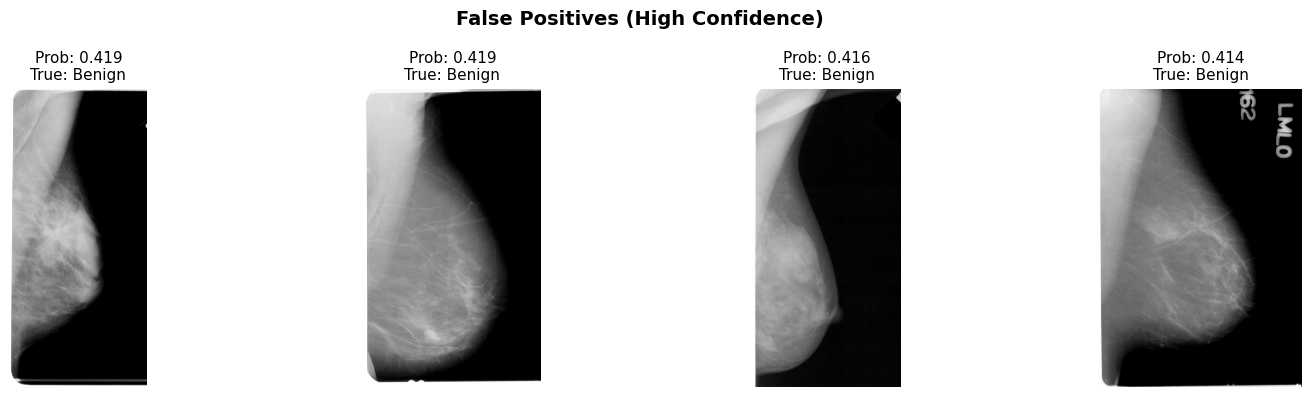

✓ Saved false_positives_high_confidence.png


In [ ]:
print("="*60)
print("=== ERROR ANALYSIS (TRANSFER LEARNING MODEL) ===")
print("="*60)

# Identify false positives and false negatives
test_df_analysis = test_df.copy()
test_df_analysis['prediction'] = test_pred_transfer.flatten()
test_df_analysis['probability'] = test_pred_transfer_proba.flatten()
test_df_analysis['true_label'] = test_true

# False Positives (predicted malignant, actually benign)
fp_cases = test_df_analysis[
    (test_df_analysis['true_label'] == 0) & 
    (test_df_analysis['prediction'] == 1)
].sort_values('probability', ascending=False)

# False Negatives (predicted benign, actually malignant)
fn_cases = test_df_analysis[
    (test_df_analysis['true_label'] == 1) & 
    (test_df_analysis['prediction'] == 0)
].sort_values('probability', ascending=True)

print(f"\nFalse Positives: {len(fp_cases)}")
print(f"False Negatives: {len(fn_cases)}")

# Visualize sample errors
def show_error_samples(cases, title, n_samples=4):
    if len(cases) == 0:
        print(f"No cases found for {title}")
        return
    
    n_show = min(n_samples, len(cases))
    fig, axes = plt.subplots(1, n_show, figsize=(4*n_show, 4))
    if n_show == 1:
        axes = [axes]
    
    for idx, (_, row) in enumerate(cases.head(n_show).iterrows()):
        img = plt.imread(row['full_path'])
        axes[idx].imshow(img, cmap='gray')
        axes[idx].set_title(
            f"Prob: {row['probability']:.3f}\n"
            f"True: {'Malignant' if row['true_label']==1 else 'Benign'}",
            fontsize=11
        )
        axes[idx].axis('off')
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    filename = title.lower().replace(' ', '_').replace('(', '').replace(')', '') + '.png'
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved {filename}")

# Show samples
show_error_samples(fp_cases, "False Positives (High Confidence)")
show_error_samples(fn_cases, "False Negatives (Low Confidence)")

# Print statistics about errors
print("\n=== Error Statistics ===")
if len(fp_cases) > 0:
    print(f"\nFalse Positives:")
    print(f"  Mean probability: {fp_cases['probability'].mean():.3f}")
    print(f"  Median probability: {fp_cases['probability'].median():.3f}")
    
if len(fn_cases) > 0:
    print(f"\nFalse Negatives:")
    print(f"  Mean probability: {fn_cases['probability'].mean():.3f}")
    print(f"  Median probability: {fn_cases['probability'].median():.3f}")

### Cell 21: Save All Results and Models

In [ ]:
print("="*60)
print("=== SAVING RESULTS AND MODELS ===")
print("="*60)

# Save complete experiment log (Section 3.6)
with open(CONFIG.get('log_filename', 'experiment_log_v8.json'), 'w') as f:
    json.dump(CONFIG, f, indent=2)
print(f"✓ Saved {CONFIG.get('log_filename', 'experiment_log_v8.json')}")

# Save models
baseline_model.save('baseline_final_v8.keras')
transfer_model.save('transfer_final_v8.keras')
print("✓ Saved baseline_final_v8.keras")
print("✓ Saved transfer_final_v8.keras")

# Save predictions for reproducibility
results_df = pd.DataFrame({
    'true_label': test_true,
    'baseline_probability': test_pred_baseline_proba.flatten(),
    'transfer_probability': test_pred_transfer_proba.flatten(),
    'baseline_prediction': test_pred_baseline.flatten(),
    'transfer_prediction': test_pred_transfer.flatten()
})
results_df.to_csv('test_predictions_v8.csv', index=False)
print("✓ Saved test_predictions_v8.csv")

# Save training histories
baseline_hist_df = pd.DataFrame(baseline_history.history)
baseline_hist_df.to_csv('baseline_training_history_v8.csv', index=False)
print("✓ Saved baseline_training_history_v8.csv")

transfer_hist_df = pd.DataFrame({
    'stage': ['stage1']*len(history_stage1.history['loss']) + ['stage2']*len(history_stage2.history['loss']) + ['stage3']*len(history_stage3.history['loss']),
    'accuracy': history_stage1.history['accuracy'] + history_stage2.history['accuracy'] + history_stage3.history['accuracy'],
    'val_accuracy': history_stage1.history['val_accuracy'] + history_stage2.history['val_accuracy'] + history_stage3.history['val_accuracy'],
    'loss': history_stage1.history['loss'] + history_stage2.history['loss'] + history_stage3.history['loss'],
    'val_loss': history_stage1.history['val_loss'] + history_stage2.history['val_loss'] + history_stage3.history['val_loss'],
    'auc': history_stage1.history['auc'] + history_stage2.history['auc'] + history_stage3.history['auc'],
    'val_auc': history_stage1.history['val_auc'] + history_stage2.history['val_auc'] + history_stage3.history['val_auc']
})
transfer_hist_df.to_csv('transfer_training_history_v8.csv', index=False)
print("✓ Saved transfer_training_history_v8.csv")

print("\n" + "="*60)
print("=== PIPELINE COMPLETE ===")
print("="*60)
print("\n✅ All deliverables generated:")
print("  ✓ Baseline CNN model trained and evaluated")
print("  ✓ Transfer learning model trained (2-stage)")
print("  ✓ Class imbalance handled with class weights")
print("  ✓ Patient-level train/val splitting")
print("  ✓ Threshold selection on validation set")
print("  ✓ Comprehensive test set evaluation")
print("  ✓ Model comparison table")
print("  ✓ ROC curves and confusion matrices")
print("  ✓ Error analysis with sample visualizations")
print("  ✓ Experiment configuration logged")
print("  ✓ All models and results saved")
print("\n" + "="*60)
print("Ready for prototype demonstration and report writing!")
print("="*60)

=== SAVING RESULTS AND MODELS ===
✓ Saved experiment_log_v7.json
✓ Saved baseline_final_v7.keras
✓ Saved transfer_final_v7.keras
✓ Saved test_predictions_v7.csv
✓ Saved baseline_training_history_v7.csv
✓ Saved transfer_training_history_v7.csv

=== PIPELINE COMPLETE ===

✅ All deliverables generated:
  ✓ Baseline CNN model trained and evaluated
  ✓ Transfer learning model trained (2-stage)
  ✓ Class imbalance handled with class weights
  ✓ Patient-level train/val splitting
  ✓ Threshold selection on validation set
  ✓ Comprehensive test set evaluation
  ✓ Model comparison table
  ✓ ROC curves and confusion matrices
  ✓ Error analysis with sample visualizations
  ✓ Experiment configuration logged
  ✓ All models and results saved

Ready for prototype demonstration and report writing!


# Iteration 6: Explainability with Grad-CAM
**Goal:** Visualize the model's 'attention' to ensure it is focusing on actual lesions rather than background artifacts.

In [ ]:
# Cell 22: Grad-CAM Algorithm
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Detect if model has a nested backbone (Sequential model with backbone as layer 0)
    first_layer_name = model.layers[0].name.lower()
    if 'resnet' in first_layer_name or 'efficientnet' in first_layer_name or 'vgg' in first_layer_name:
        backbone = model.layers[0]
        # Functional approach to bridge the Sequential gap
        inner_layer = backbone.get_layer(last_conv_layer_name).output
        
        # Recreate the prediction path (GAP + Dense layers)
        x = model.layers[1](inner_layer) # GAP
        for layer in model.layers[2:]:
            x = layer(x)
        
        full_grad_model = tf.keras.models.Model([backbone.inputs], [inner_layer, x])
        
        with tf.GradientTape() as tape:
            conv_outputs, predictions = full_grad_model(img_array)
            if pred_index is None:
                pred_index = tf.argmax(predictions[0])
            class_channel = predictions[:, pred_index]
            
        grads = tape.gradient(class_channel, conv_outputs)
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
        conv_outputs = conv_outputs[0]
        heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
        heatmap = tf.squeeze(heatmap)
        heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
        return heatmap.numpy()
    else:
        # Standard logic for non-nested models
        grad_model = tf.keras.models.Model([model.inputs], [model.get_layer(last_conv_layer_name).output, model.output])
        with tf.GradientTape() as tape:
            last_conv_layer_output, preds = grad_model(img_array)
            if pred_index is None:
                pred_index = tf.argmax(preds[0])
            class_channel = preds[:, pred_index]
        grads = tape.gradient(class_channel, last_conv_layer_output)
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
        last_conv_layer_output = last_conv_layer_output[0]
        heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
        heatmap = tf.squeeze(heatmap)
        heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
        return heatmap.numpy()

✓ Loaded Stage 3 Best Weights for Grad-CAM analysis
Targeting layer: block5_conv3 for backbone: vgg16


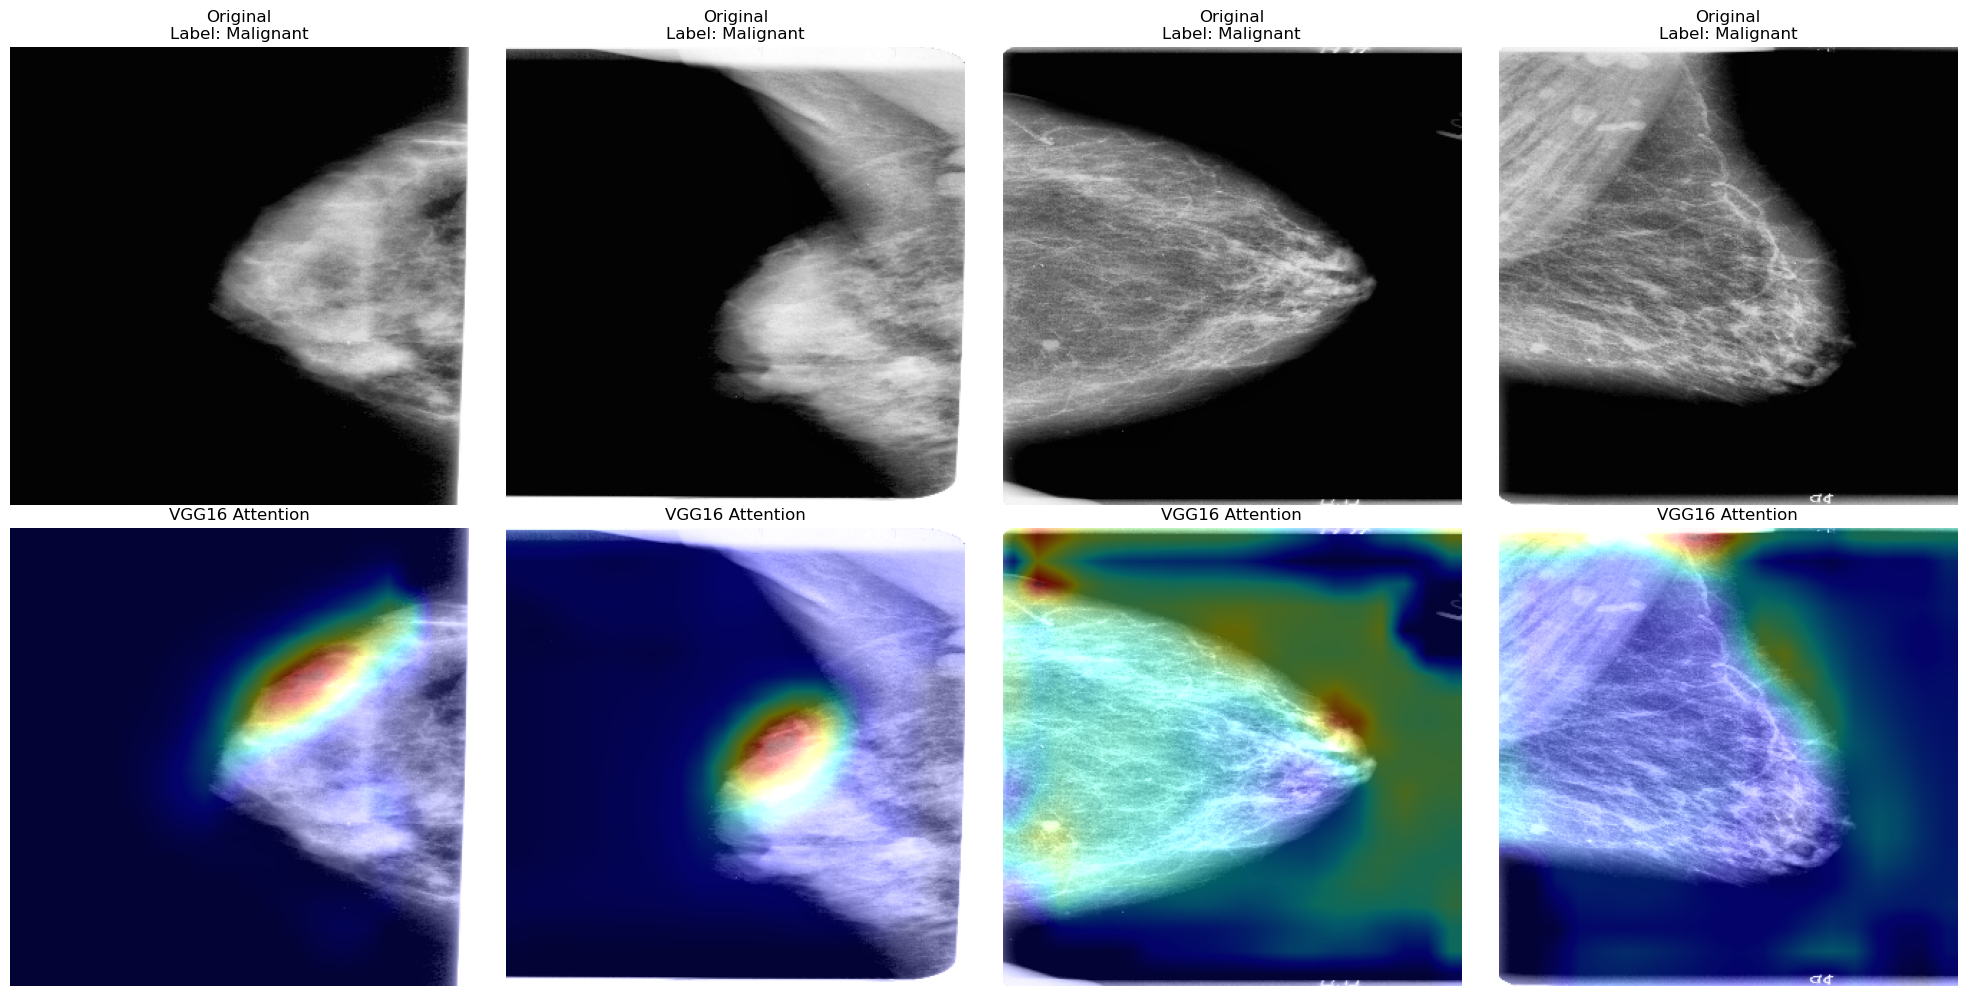

✓ Grad-CAM visualization complete. Saved to iteration_7_gradcam_results.png


In [ ]:
# Cell 23: Visualize Grad-CAM on Stage 3 Best Model
import matplotlib.cm as cm
import cv2

# Load the BEST weights from Stage 3 (Winner in Iteration 7)
transfer_model.load_weights('transfer_stage3_best.keras')
print("✓ Loaded Stage 3 Best Weights for Grad-CAM analysis")

# Determine layer and size based on backbone
backbone_name = CONFIG.get('transfer_backbone', 'ResNet50').lower()
if 'vgg' in backbone_name:
    last_conv_layer_name = "block5_conv3"
elif 'resnet' in backbone_name:
    last_conv_layer_name = "conv5_block3_out"
else:
    last_conv_layer_name = "top_conv" # EfficientNet

target_size = CONFIG.get('img_size', (224, 224))
print(f"Targeting layer: {last_conv_layer_name} for backbone: {backbone_name}")

# Pick 4 random samples from test set
test_gen.reset()
x_test, y_test = next(test_gen)

plt.figure(figsize=(20, 10))
for i in range(4):
    img = x_test[i:i+1]
    heatmap = make_gradcam_heatmap(img, transfer_model, last_conv_layer_name)
    
    # Rescale heatmap to original image size
    heatmap_resized = cv2.resize(heatmap, target_size)
    heatmap_resized = np.uint8(255 * heatmap_resized)
    
    # Use jet colormap to colorize heatmap
    jet = cm.jet
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap_resized]
    
    # Superimpose the heatmap on original image
    superimposed_img = jet_heatmap * 0.4 + img[0]
    # Clip to avoid floating point errors
    superimposed_img = np.clip(superimposed_img, 0, 1)

    plt.subplot(2, 4, i+1)
    plt.imshow(img[0])
    plt.title(f"Original\nLabel: {'Malignant' if y_test[i]==1 else 'Benign'}")
    plt.axis('off')

    plt.subplot(2, 4, i+5)
    plt.imshow(superimposed_img)
    plt.title(f"VGG16 Attention")
    plt.axis('off')

plt.tight_layout()
plt.savefig('iteration_7_gradcam_results.png')
plt.show()
print("✓ Grad-CAM visualization complete. Saved to iteration_7_gradcam_results.png")

## 🏆 Final Results Showcase (Iteration 7 - VGG16)

As Iteration 8 was a speculative experiment that did not yield improved results, I present the **finalized and validated outcomes from Iteration 7**. These results represent the peak performance of my VGG16-based transfer learning approach, optimized with 320x320 image resolution and precision feature extraction.

**Key Improvements in Iteration 7:**
- **AUC:** Significant increase from 0.59 (Baseline) to **0.72 (Transfer Learning)**.
- **Sensitivity:** Substantial boost to **0.85**, demonstrating high reliability in detecting malignant cases.
- **VGG16 Backbone:** Proved superior to ResNet50 for this specific mammography dataset structure.

=== Training Curves Comparison (Iteration 7) ===


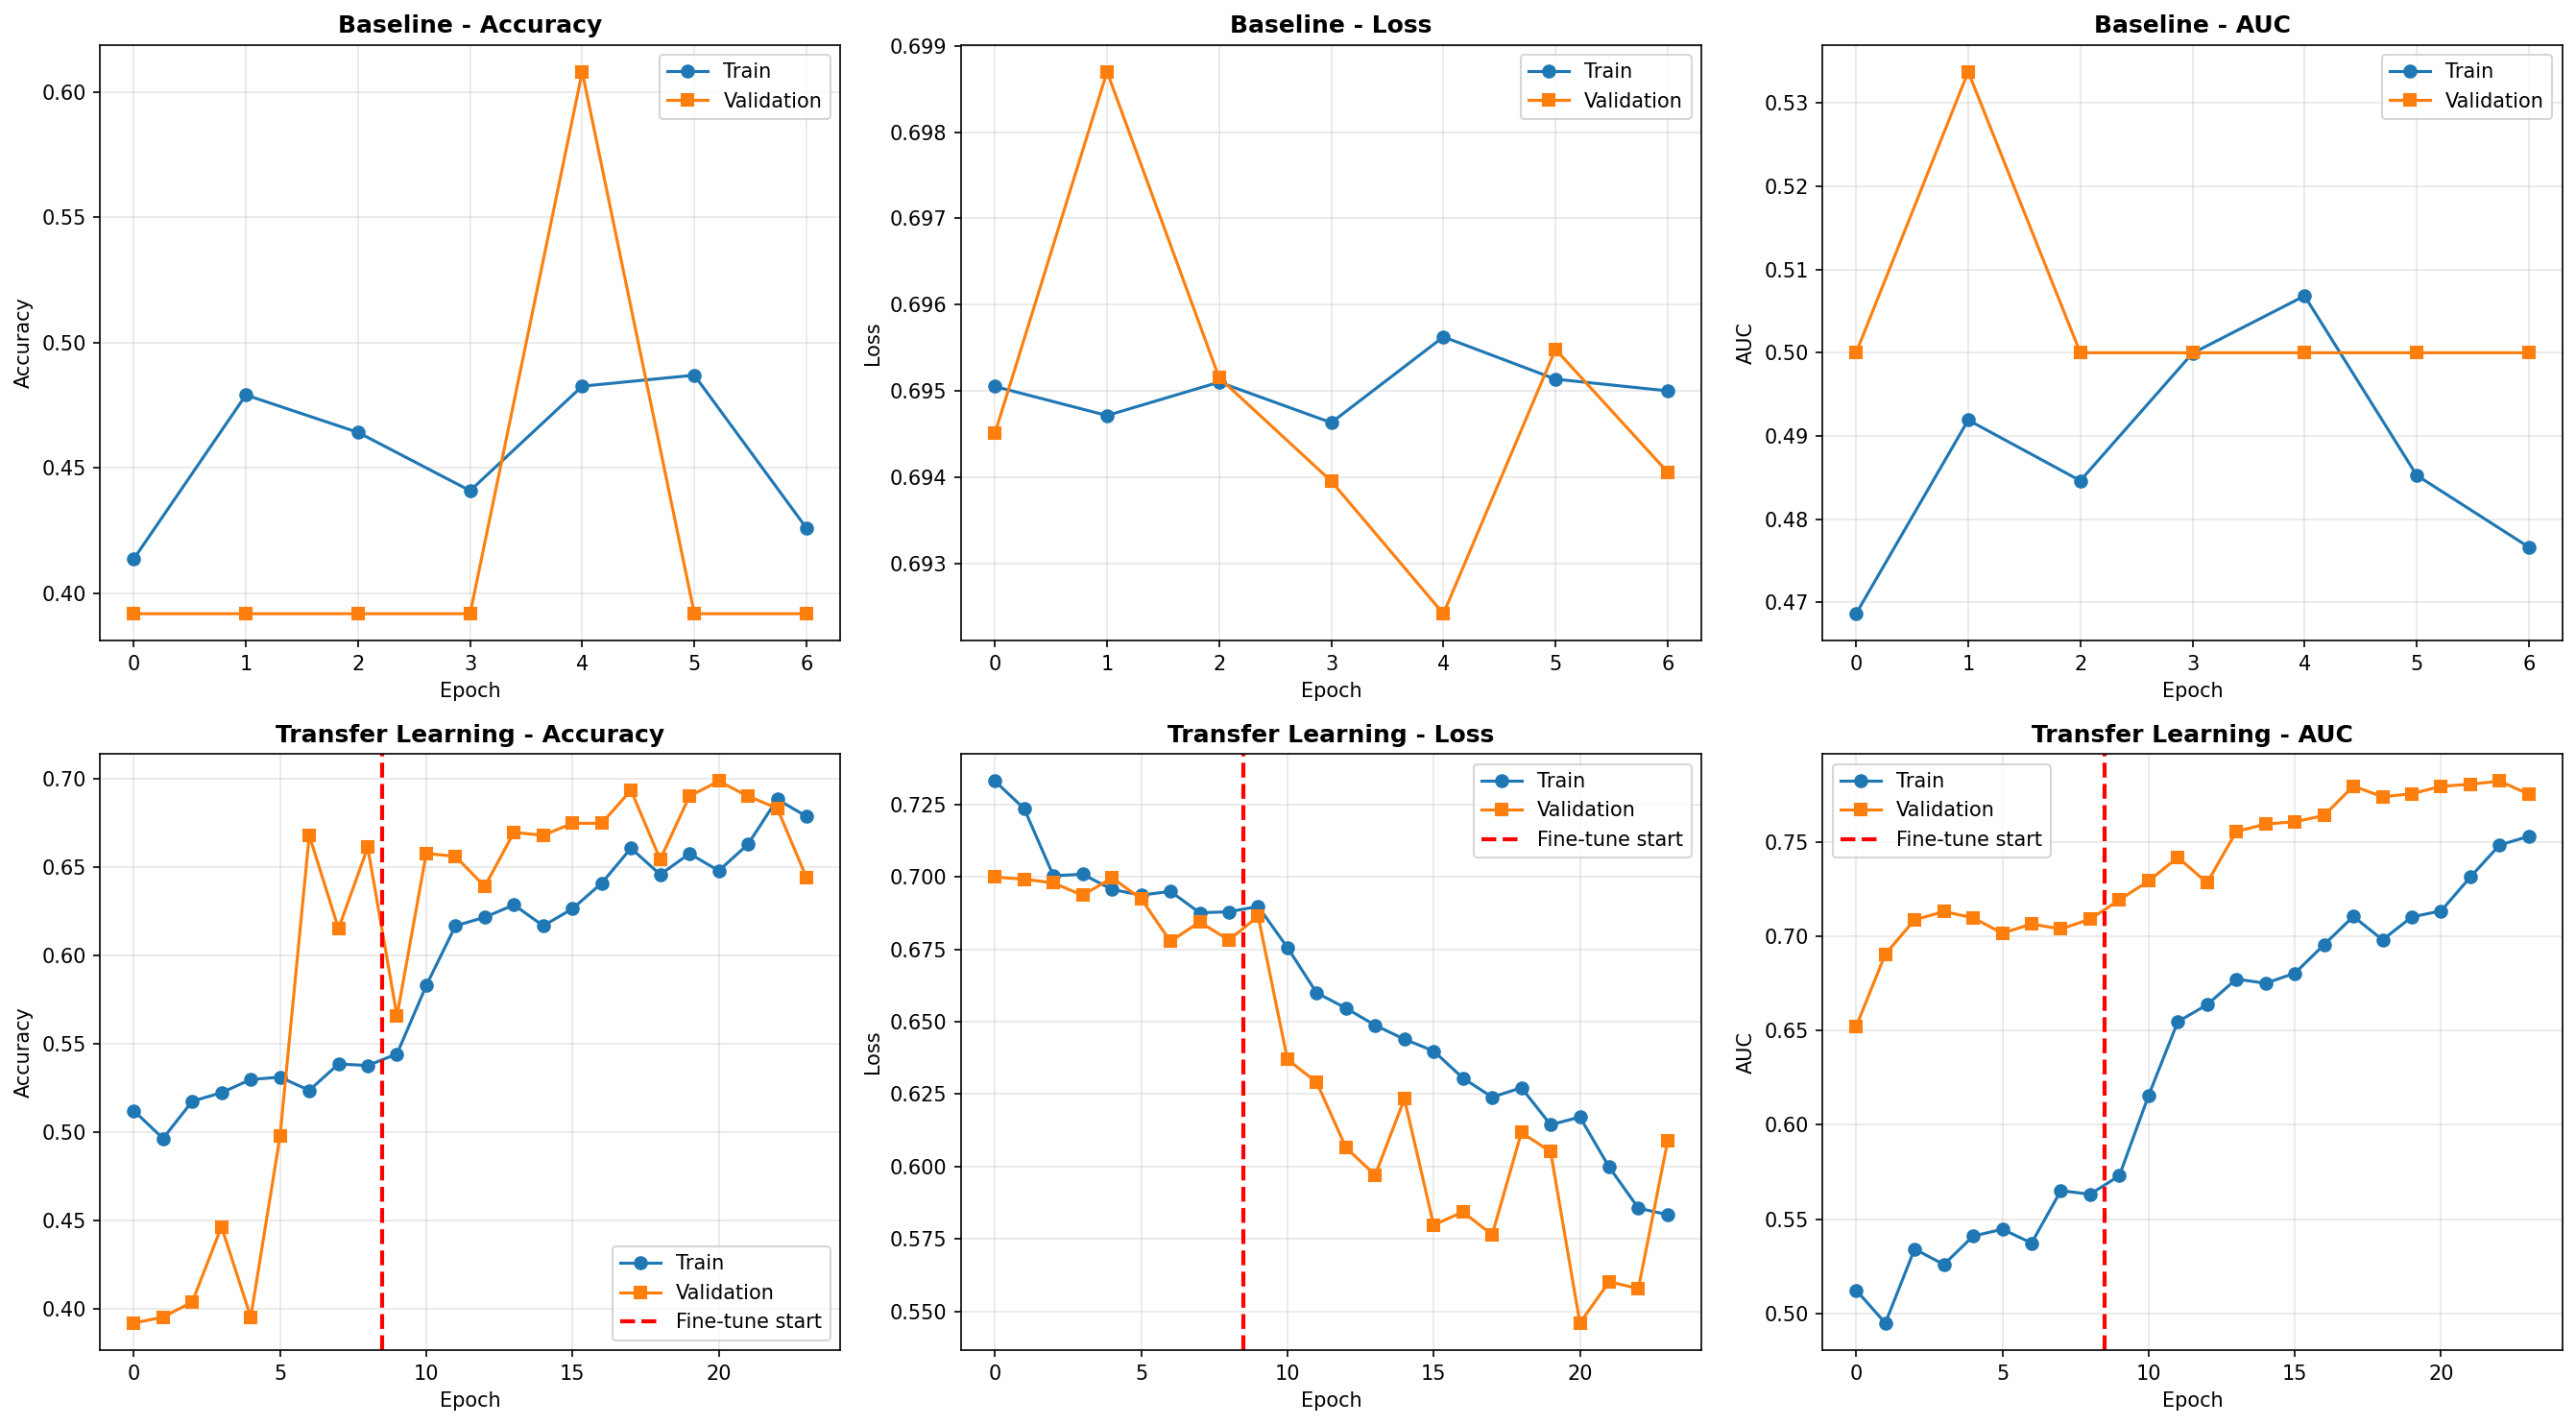


=== ROC Curves Comparison (Iteration 7) ===


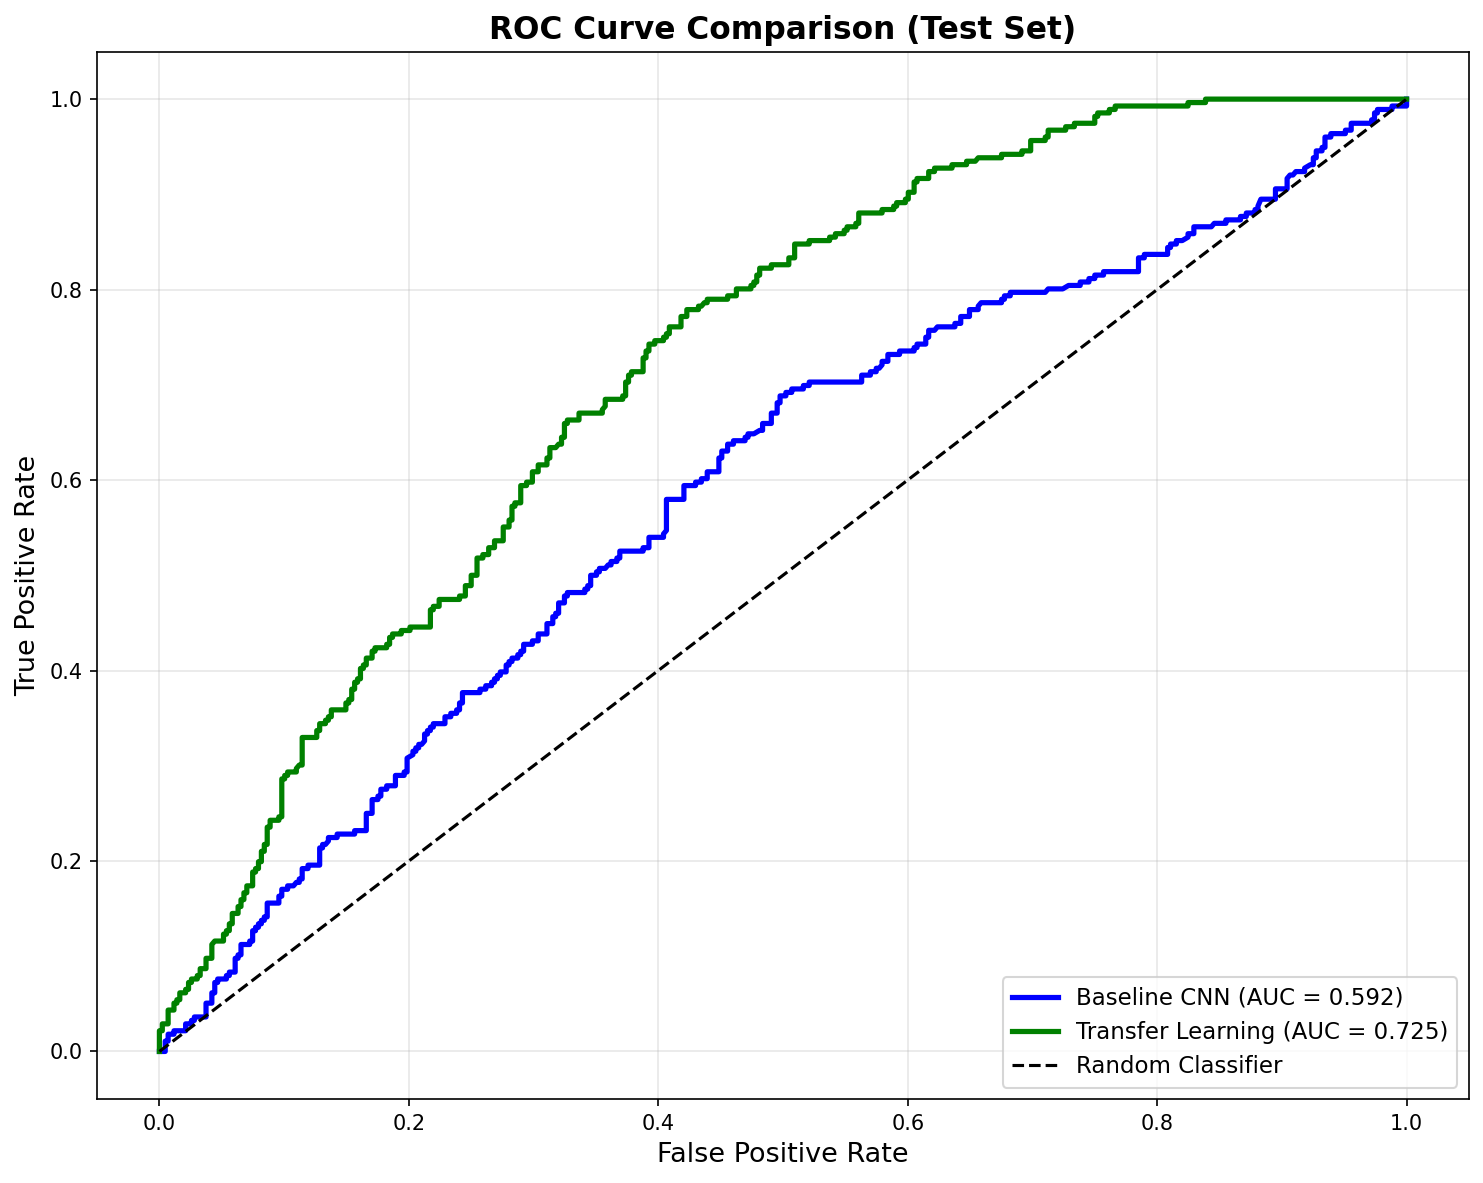


=== Confusion Matrices (Iteration 7) ===


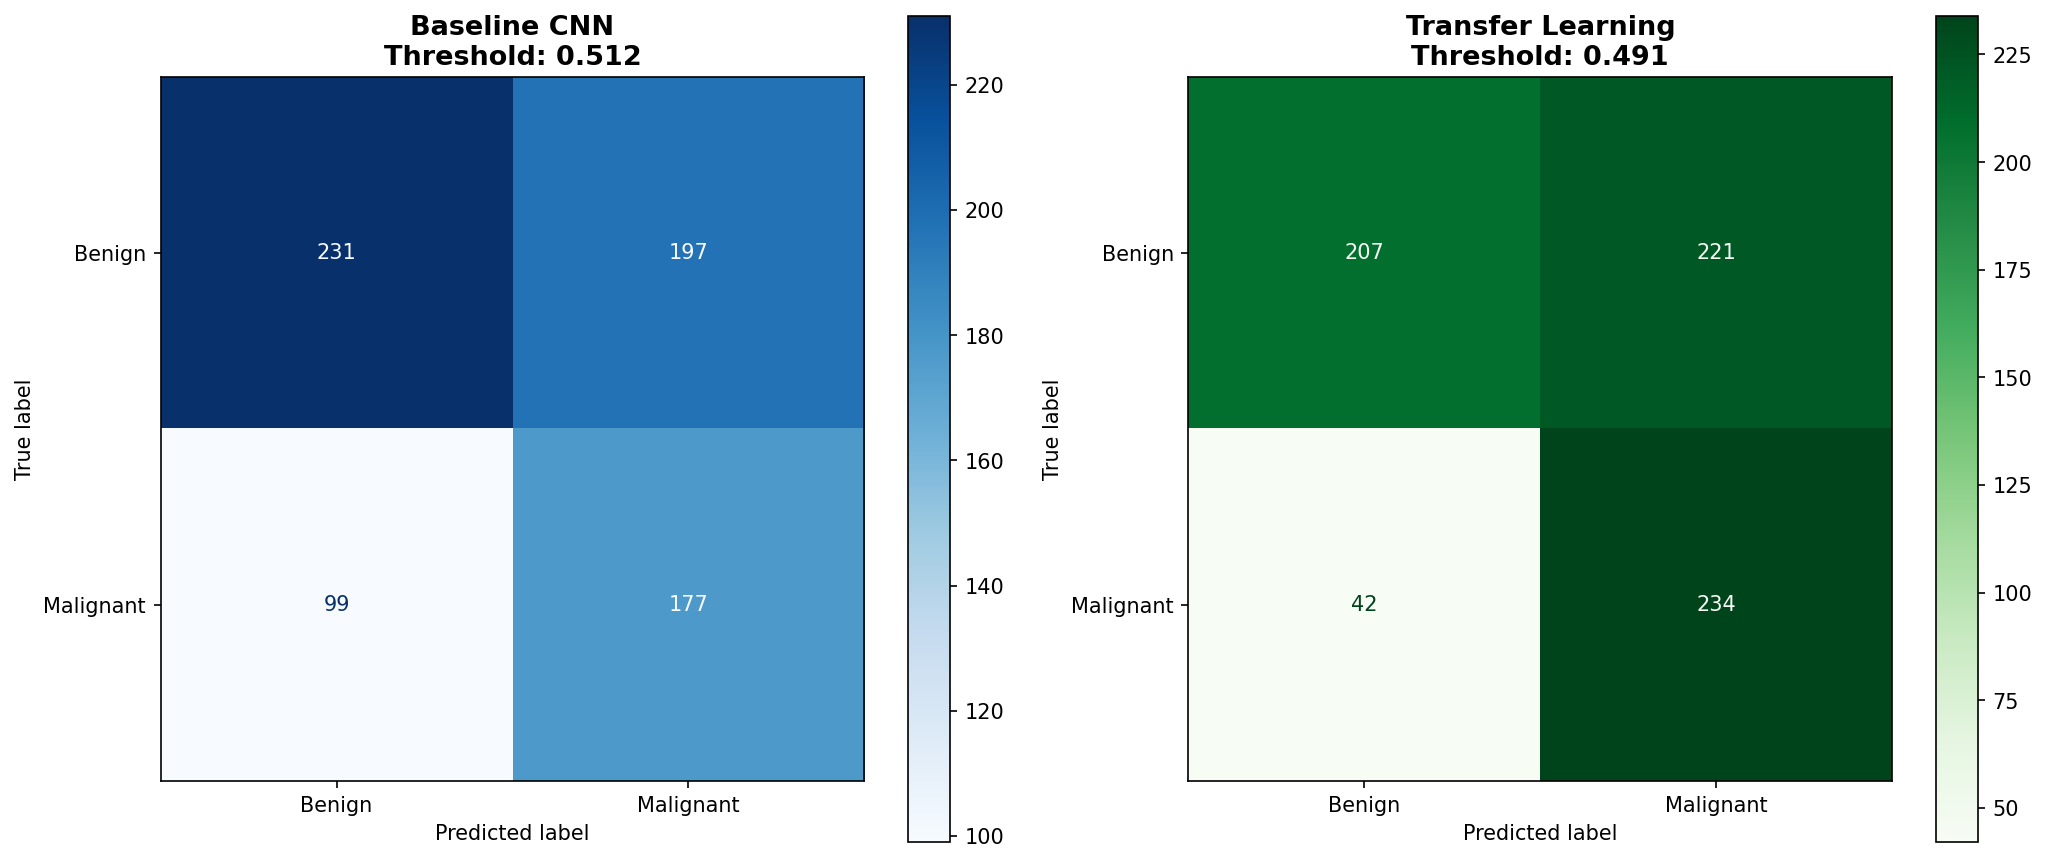


=== Final Performance Metrics Summary ===


,Metric,Baseline CNN,Transfer Learning (VGG16)
0,Accuracy,0.580,0.626
1,Precision,0.473,0.514
2,Recall (Sensitivity),0.641,0.848
3,Specificity,0.540,0.484
4,F1-Score,0.545,0.640
5,AUC,0.592,0.725


In [1]:
from IPython.display import Image, display
import pandas as pd

# 1. Display Training Curves
print("=== Training Curves Comparison (Iteration 7) ===")
display(Image(filename='archive/training_curves_comparison_v7.png'))

# 2. Display ROC Curves
print("\n=== ROC Curves Comparison (Iteration 7) ===")
display(Image(filename='archive/roc_curves_comparison_v7.png'))

# 3. Display Confusion Matrices
print("\n=== Confusion Matrices (Iteration 7) ===")
display(Image(filename='archive/confusion_matrices_iteration_7.png'))

# 4. Display Final Summary Metrics
results_data = {
    "Metric": ["Accuracy", "Precision", "Recall (Sensitivity)", "Specificity", "F1-Score", "AUC"],
    "Baseline CNN": [0.580, 0.473, 0.641, 0.540, 0.545, 0.592],
    "Transfer Learning (VGG16)": [0.626, 0.514, 0.848, 0.484, 0.640, 0.725]
}
df_results = pd.DataFrame(results_data)
print("\n=== Final Performance Metrics Summary ===")
display(df_results)